In [1]:

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torchvision.datasets as datasets
import torchvision.transforms as T

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
#  Download and load PASCAL VOC 2012 Validation set
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

print("Loading PASCAL VOC 2012 Validation set...")
voc_dataset = datasets.VOCDetection(
    root=DATA_DIR,
    year='2012',
    image_set='val',
    download=True  # Set to False once data is already downloaded
)

print(f"Successfully loaded {len(voc_dataset)} images from PASCAL VOC 2012!")

Loading PASCAL VOC 2012 Validation set...


/usr/lib64/python3.9/tarfile.py:2288: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


Successfully loaded 5823 images from PASCAL VOC 2012!


In [3]:
#Define classes and helper functions for VOC format
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

def extract_voc_objects(target):
    """
    Extracts bounding boxes and labels from the VOC annotation dictionary.
    """
    objects = target['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
        
    bboxes = []
    labels = []
    for obj in objects:
        label = obj['name']
        bndbox = obj['bndbox']
        bbox = [
            int(bndbox['xmin']),
            int(bndbox['ymin']),
            int(bndbox['xmax']),
            int(bndbox['ymax'])
        ]
        bboxes.append(bbox)
        labels.append(label)
        
    return bboxes, labels

print("Helper functions ready!")

Helper functions ready!


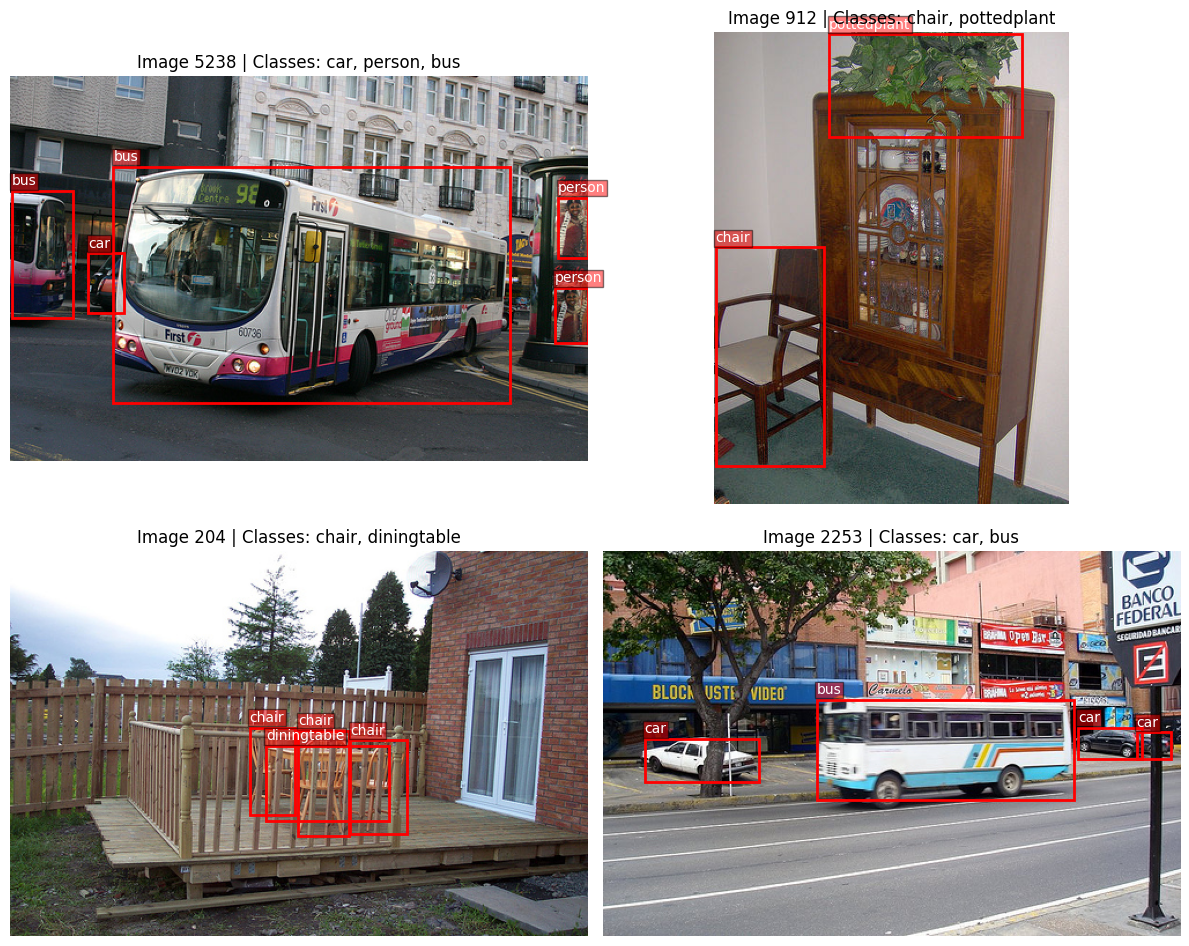

In [4]:
#  Visualization (EDA) - Display a grid of random images with Bounding Boxes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i in range(4):
    # Select a random image index
    idx = random.randint(0, len(voc_dataset) - 1)
    img, target = voc_dataset[idx]
    
    # Get bounding boxes and labels
    bboxes, labels = extract_voc_objects(target)
    
    # Display the image
    axes[i].imshow(img)
    axes[i].axis('off')
    
    unique_labels = list(set(labels))
    axes[i].set_title(f"Image {idx} | Classes: {', '.join(unique_labels)}")
    
    # Draw bounding boxes
    for bbox, label in zip(bboxes, labels):
        xmin, ymin, xmax, ymax = bbox
        width = xmax - xmin
        height = ymax - ymin
        
        # Create a Rectangle patch
        rect = patches.Rectangle((xmin, ymin), width, height, 
                                 linewidth=2, edgecolor='red', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(xmin, ymin - 5, label, color='white', fontsize=10,
                     bbox=dict(facecolor='red', alpha=0.5, pad=1))

plt.tight_layout()
plt.show()

In [5]:
# Extract exactly 100 images, convert to tensors, and save locally
import torch
import torchvision.transforms as T

# Initialize lists to hold the 100 images and annotations
processed_images_list = []
processed_labels_list = []

# Define a transform to convert PIL images to PyTorch tensors
transform = T.ToTensor()

num_images_to_save = 100
print(f"Extracting and processing {num_images_to_save} images...")

for i in range(num_images_to_save):
    # Get image and target (annotation) from the VOC dataset
    img, target = voc_dataset[i]
    
    # Convert PIL Image to PyTorch Tensor (Values between 0.0 and 1.0)
    img_tensor = transform(img)
    
    # Extract bounding boxes and labels using the helper function we defined in Cell 3
    bboxes, labels = extract_voc_objects(target)
    
    # Save the processed data to our lists
    processed_images_list.append(img_tensor)
    processed_labels_list.append({
        'bboxes': bboxes, 
        'labels': labels
    })

# Create the dictionary to save everything together
data_to_save = {
    'images': processed_images_list,
    'annotations': processed_labels_list
}

# Save to a single, clean local file
file_name = 'voc_100_subset.pt'
torch.save(data_to_save, file_name)

print(f"Success! Saved {len(processed_images_list)} images and their annotations to '{file_name}'.")

Extracting and processing 100 images...
Success! Saved 100 images and their annotations to 'voc_100_subset.pt'.


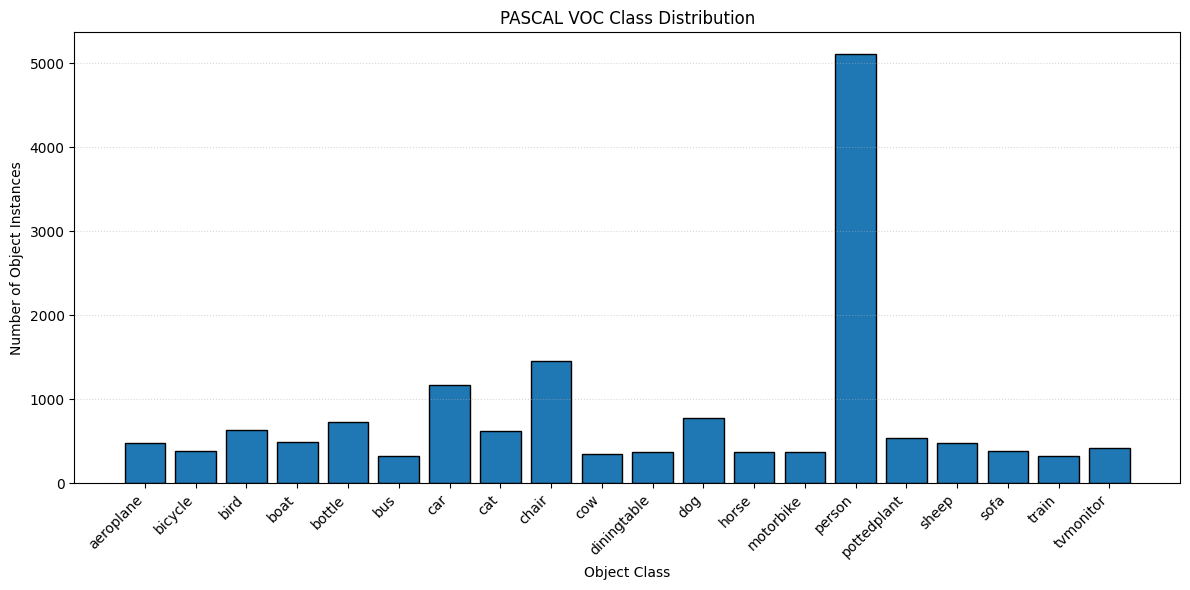

Saved: results/figures/eda_class_distribution.png


In [6]:
# Class Distribution Plot for PASCAL VOC

from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure FIGURES_DIR exists
FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

class_counter = Counter()

for _, target in voc_dataset:
    objects = target["annotation"]["object"]

    # If there is only one object, VOC may store it as a dictionary
    if isinstance(objects, dict):
        objects = [objects]

    for obj in objects:
        class_counter[obj["name"]] += 1

# Sort by class name
classes = sorted(class_counter.keys())
counts = [class_counter[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts, edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Object Class")
plt.ylabel("Number of Object Instances")
plt.title("PASCAL VOC Class Distribution")
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()

save_path = FIGURES_DIR / "eda_class_distribution.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

Found 3 segmentation examples.


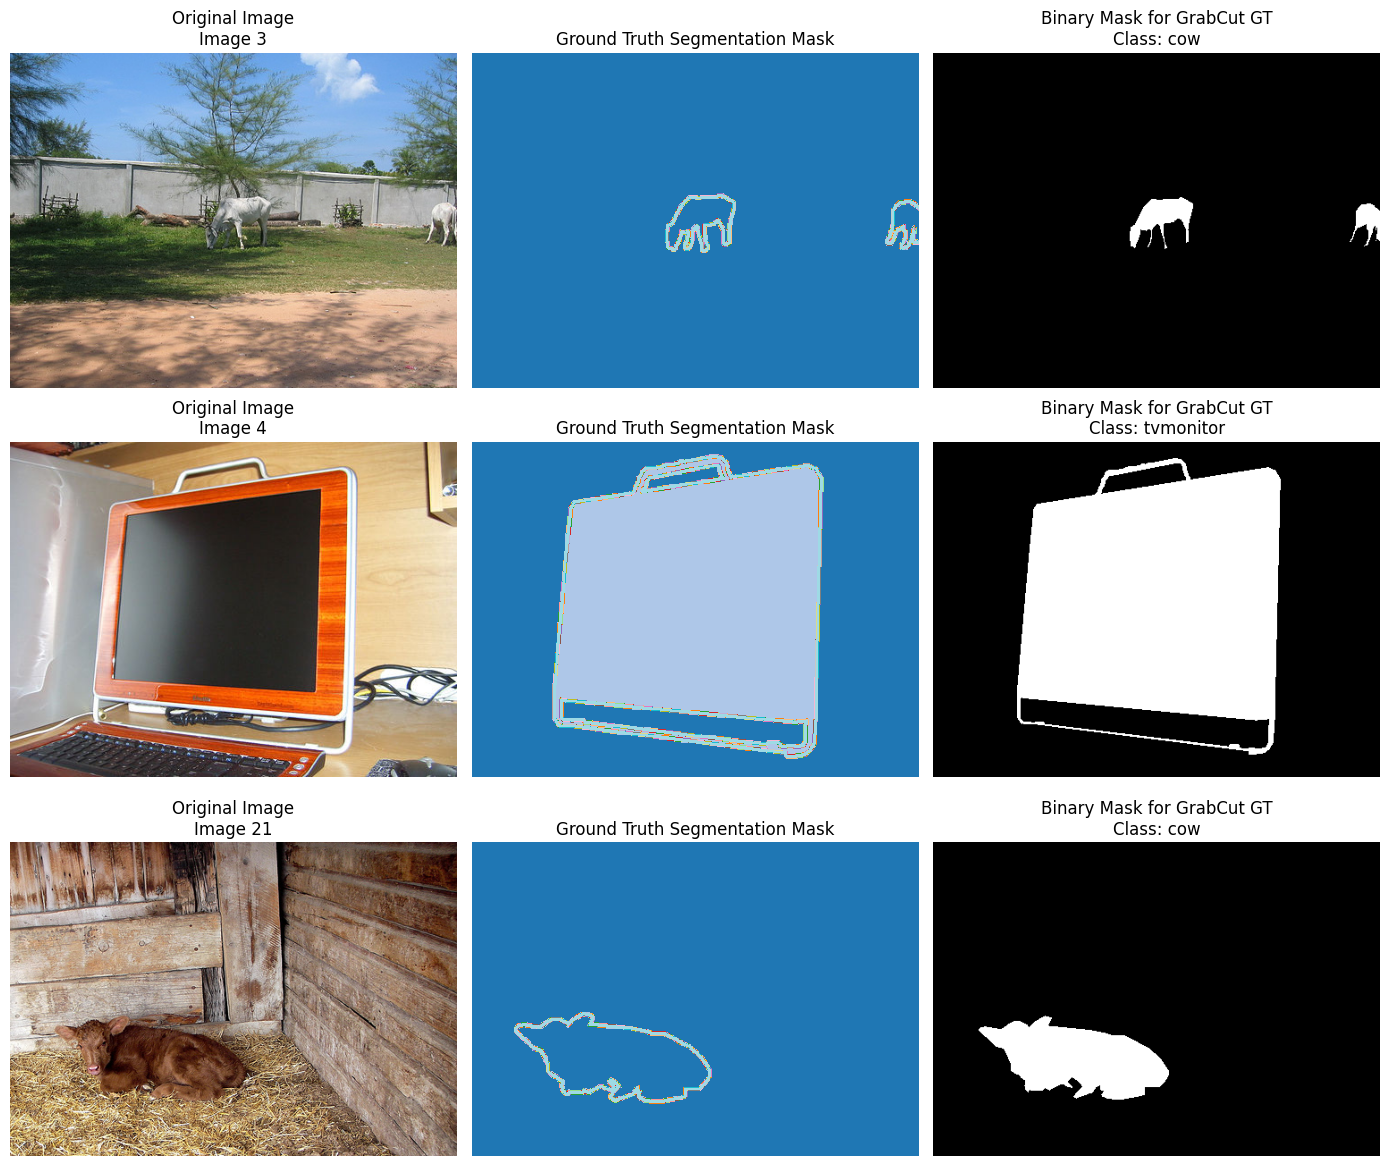

Saved: results/figures/eda_segmentation_examples.png


In [7]:
# EDA: Ground Truth Segmentation Mask Examples

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# ---------------------------------------------------------
# Make sure output folder exists
# ---------------------------------------------------------
FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# VOC class list
# ---------------------------------------------------------
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

VOC_CLASS_TO_INDEX = {cls_name: idx for idx, cls_name in enumerate(VOC_CLASSES)}

# ---------------------------------------------------------
# Find segmentation directory
# ---------------------------------------------------------
DATA_DIR = Path("data")
SEGMENTATION_DIR = DATA_DIR / "VOCdevkit" / "VOC2012" / "SegmentationClass"

if not SEGMENTATION_DIR.exists():
    raise FileNotFoundError(
        f"Segmentation folder not found: {SEGMENTATION_DIR}\n"
        "Make sure PASCAL VOC 2012 is downloaded."
    )

# ---------------------------------------------------------
# Helper: handle one/multiple objects
# ---------------------------------------------------------
def get_objects(target):
    objects = target["annotation"]["object"]
    if isinstance(objects, dict):
        objects = [objects]
    return objects


def get_largest_object(target):
    objects = get_objects(target)

    largest_obj = None
    largest_area = 0

    for obj in objects:
        bbox = obj["bndbox"]

        xmin = int(float(bbox["xmin"]))
        ymin = int(float(bbox["ymin"]))
        xmax = int(float(bbox["xmax"]))
        ymax = int(float(bbox["ymax"]))

        area = max(0, xmax - xmin) * max(0, ymax - ymin)

        if area > largest_area:
            largest_area = area
            largest_obj = obj

    return largest_obj


# ---------------------------------------------------------
# Collect examples that have segmentation masks
# ---------------------------------------------------------
examples = []

for idx in range(len(voc_dataset)):
    img, target = voc_dataset[idx]

    filename = target["annotation"]["filename"]
    stem = Path(filename).stem
    seg_path = SEGMENTATION_DIR / f"{stem}.png"

    if not seg_path.exists():
        continue

    largest_obj = get_largest_object(target)

    if largest_obj is None:
        continue

    class_name = largest_obj["name"]

    if class_name not in VOC_CLASS_TO_INDEX:
        continue

    examples.append((idx, img, target, seg_path, class_name))

    if len(examples) == 3:
        break

print(f"Found {len(examples)} segmentation examples.")

# ---------------------------------------------------------
# Plot examples
# ---------------------------------------------------------
fig, axes = plt.subplots(len(examples), 3, figsize=(14, 4 * len(examples)))

if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (idx, img, target, seg_path, class_name) in enumerate(examples):
    image_np = np.array(img.convert("RGB"))
    seg_mask = np.array(Image.open(seg_path))

    # PASCAL VOC segmentation IDs:
    # 0 = background
    # 1-20 = object classes
    # 255 = boundary / ignore
    class_id = VOC_CLASS_TO_INDEX[class_name] + 1

    binary_mask = (seg_mask == class_id).astype(np.uint8)

    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(f"Original Image\nImage {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(seg_mask, cmap="tab20")
    axes[row, 1].set_title("Ground Truth Segmentation Mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(binary_mask, cmap="gray")
    axes[row, 2].set_title(f"Binary Mask for GrabCut GT\nClass: {class_name}")
    axes[row, 2].axis("off")

plt.tight_layout()

save_path = FIGURES_DIR / "eda_segmentation_examples.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", save_path)